In [1]:
# Important libraries 
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
file_path = r"D:\BPS\dataset\2025\all_attack_benign_samples\reduced_dataset.csv" 
#determine target 
target = "target"

In [3]:
df = pd.read_csv(file_path)

In [4]:
df.shape

(154856, 26)

In [5]:
# separate features and target 
X = df.drop(columns=[target])
y = df[target]

In [6]:
#keep numerical only
X = X.select_dtypes(include=[np.number]).copy()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (123884, 25)
Test shape: (30972, 25)


In [8]:
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(
        class_weight="balanced",
        max_iter=5000,
        dual=False,
        random_state=42
    ))
])

In [9]:
model.fit(X_train, y_train)
print("Training ok.")

Training ok.


In [10]:
y_pred = model.predict(X_test)

In [11]:
positive_class = 1

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=positive_class)
recall = recall_score(y_test, y_pred, pos_label=positive_class)
f1 = f1_score(y_test, y_pred, pos_label=positive_class)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.9751711223040165
Precision: 0.9209123222748815
Recall: 0.8609803378565495
F1-score: 0.8899384571346787

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99     27361
           1       0.92      0.86      0.89      3611

    accuracy                           0.98     30972
   macro avg       0.95      0.93      0.94     30972
weighted avg       0.97      0.98      0.97     30972

Confusion Matrix:

[[27094   267]
 [  502  3109]]


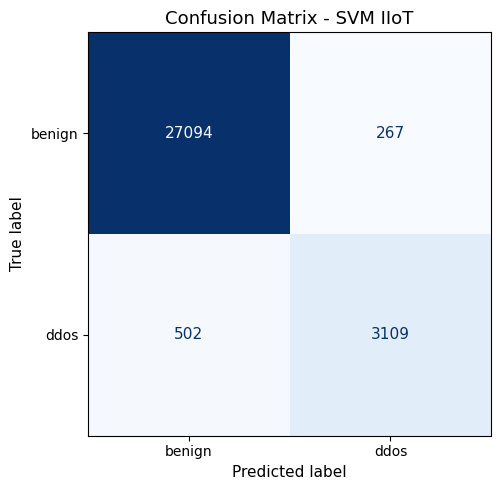

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6,5))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["benign", "ddos"],
    cmap="Blues",
    ax=ax,
    colorbar=False  
)

# fix num. size 
for text in disp.text_.ravel():
    text.set_fontsize(11)

ax.set_title("Confusion Matrix - SVM IIoT", fontsize=13)
ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("True label", fontsize=11)
plt.tight_layout()
plt.savefig("Confusion Matrix - SVM IIoT", dpi=300, bbox_inches="tight")
plt.show()